In [11]:
import os
from dotenv import load_dotenv
ROOT = "../" # Base directory relative to this notebook's location. Adjust if the notebook is moved
CSV_DIR = os.path.join(ROOT, "csv", "historical-data")
JSON_DIR = os.path.join(ROOT, "json")
DOTENV_PATH = os.path.join(ROOT, '../../apis/.env') # Adjust to .env file location
if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

# Variables de ejecución avanzadas (no es necesario cambiarlas si no se ha alterado la estructura de ficheros del proyecto):
DB_FILE = "db/thematic_screener.db" # Sólo necesario si DOWNLOAD_REMOTE_DB = False
import sys
sys.path.append(ROOT)

from src.aemet_helpers import AemetClient
from src.weather_data_download import download_station_data, cast_columns
import pandas as pd
import json
import matplotlib.pyplot as plt
import time

Loaded .env from c:\Users\david\***\apis\.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


In [2]:
locations_dict = os.path.join(JSON_DIR, "locations.json")
with open(locations_dict, "r", encoding="utf-8") as f:
    locations_df = pd.DataFrame(
        list(json.load(f).items()),
        columns=["code", "location"]
    )

display(locations_df.head(5))

,code,location
0,0009X,ALFORJA
1,0016A,REUS AEROPUERTO
2,0034X,VALLS
3,0042Y,TARRAGONA FAC. GEOGRAFIA
4,0061X,PONTONS


In [3]:
client = AemetClient(API_KEY)
station_id = "0009X"
df = download_station_data(client, station_id=station_id, start_date="2021-01-01", max_retries=5, sleep_seconds=6)

Fetching data for station 0009X from 2021-01-01 to 2021-06-30...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-01-01T00:00:00UTC/fechafin/2021-06-30T00:00:00UTC/estacion/0009X (Retry 1/5)
Fetching data for station 0009X from 2021-01-01 to 2021-06-30...
✓ Retrieved 158 records (from 2021-01-01 to 2021-06-30)
Fetching data for station 0009X from 2021-07-01 to 2021-12-28...
✓ Retrieved 162 records (from 2021-07-01 to 2021-12-28)
Fetching data for station 0009X from 2021-12-29 to 2022-06-27...
✓ Retrieved 179 records (from 2021-12-29 to 2022-06-27)
Fetching data for station 0009X from 2022-06-28 to 2022-12-25...
✓ Retrieved 181 records (from 2022-06-28 to 2022-12-25)
Fetching data for station 0009X from 2022-12-26 to 2023-06-24...
✓ Retrieved 181 records (from 2022-12-26 to 2023-06-24)
Fetching data for station 0009X from 2023-06-25 to 2023-12-22...
✓ Retrieved 179 records (from 2023-06-25 to 

In [4]:
display(df.head(3))
print("...")
display(df.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,dir,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2021-01-01,0009X,ALFORJA,TARRAGONA,406,"5,0","0,0","2,5",23:55,"7,4",13:13,28,"5,0","13,3",21:50,79,92,07:00,65,19:10
1,2021-01-02,0009X,ALFORJA,TARRAGONA,406,"4,1","0,0","0,9",07:13,"7,3",13:41,27,"6,1","15,8",11:30,66,80,Varias,56,19:00
2,2021-01-03,0009X,ALFORJA,TARRAGONA,406,"3,7","0,0","-0,9",06:44,"8,3",14:28,27,"5,0","16,9",11:30,65,80,07:10,52,12:40


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,dir,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
1757,2025-12-13,0009X,ALFORJA,TARRAGONA,406,"10,3","0,0","3,9",23:30,"16,7",13:39,99,"1,9","4,4",Varias,75,100,23:50,54,11:30
1758,2025-12-14,0009X,ALFORJA,TARRAGONA,406,"8,6","16,8","3,5",05:17,"13,6",13:13,10,"1,1","5,0",22:20,88,100,Varias,72,11:50
1759,2025-12-15,0009X,ALFORJA,TARRAGONA,406,"10,6","22,2","8,1",20:06,"13,1",Varias,30,"2,2","12,5",13:40,96,100,Varias,92,06:50


In [6]:
schema_path = os.path.join(JSON_DIR, "data-fields.json")
df = cast_columns(df, schema_path)

In [7]:
df.columns
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: datetime64[ns]
indicativo: string
nombre: string
provincia: string
altitud: Int64
tmed: Float64
prec: Float64
tmin: Float64
horatmin: string
tmax: Float64
horatmax: string
dir: Int64
velmedia: Float64
racha: Float64
horaracha: string
hrMedia: Int64
hrMax: Int64
horaHrMax: string
hrMin: Int64
horaHrMin: string


In [9]:
df.to_csv(os.path.join(CSV_DIR,f"{station_id}_hist.csv"), index=False)

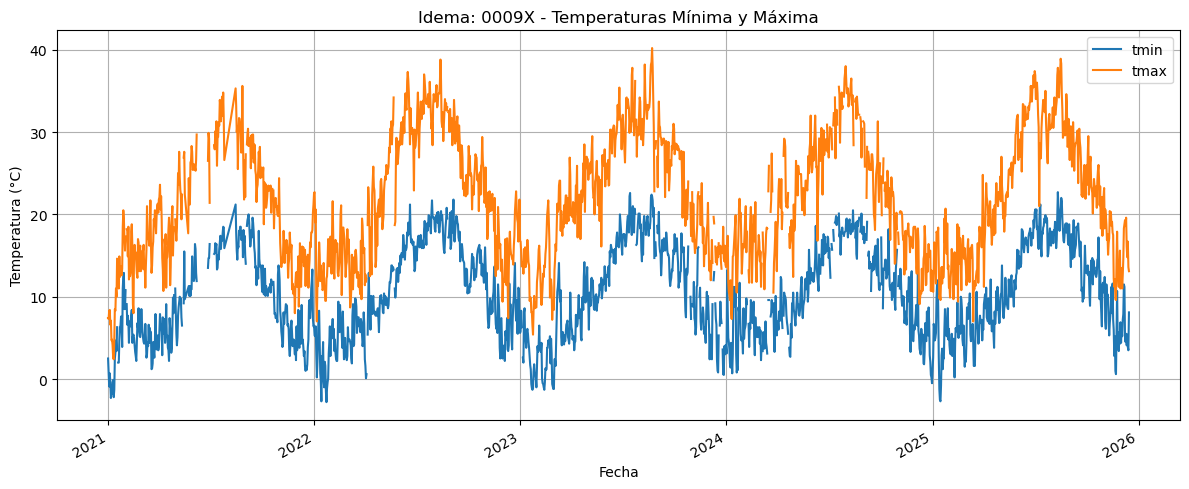

In [10]:
ax = df.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {station_id} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

### All locations

In [12]:
for station_id in locations_df["code"].astype(str).unique():
    out_path = os.path.join(CSV_DIR, f"{station_id}_hist.csv")
    if os.path.exists(out_path):
        print(f"Skipping {station_id}: file exists")
        continue
    try:
        df_loc = download_station_data(client, station_id=station_id, start_date="2021-01-01", max_retries=6, sleep_seconds=8)
        if df_loc is None or df_loc.empty:
            print(f"No data for {station_id}")
            continue
        df_loc = cast_columns(df_loc, schema_path)
        df_loc.to_csv(out_path, index=False)
        print(f"Saved {out_path}")
    except Exception as e:
        print(f"Error downloading {station_id}: {e}")
    time.sleep(1)

Skipping 0009X: file exists
Fetching data for station 0016A from 2021-01-01 to 2021-06-30...
✓ Retrieved 181 records (from 2021-01-01 to 2021-06-30)
Fetching data for station 0016A from 2021-07-01 to 2021-12-28...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-07-01T00:00:00UTC/fechafin/2021-12-28T00:00:00UTC/estacion/0016A (Retry 1/6)
Fetching data for station 0016A from 2021-07-01 to 2021-12-28...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-07-01T00:00:00UTC/fechafin/2021-12-28T00:00:00UTC/estacion/0016A (Retry 2/6)
Fetching data for station 0016A from 2021-07-01 to 2021-12-28...
✓ Retrieved 181 records (from 2021-07-01 to 2021-12-28)
Fetching data for station 0016A from 2021-12-29 to 2022-06-27...
✓ Retrieved 181 records (from 2021-12-29 to 2022-06-27)
Fetching data for station 0016A from 

KeyboardInterrupt: 